In [19]:
import pandas as pd

## **Cargamos datos "procesados"**

In [20]:
df_jan = pd.read_parquet("data/processed/jan.parquet")
df_feb = pd.read_parquet("data/processed/feb.parquet")


## **EDA**

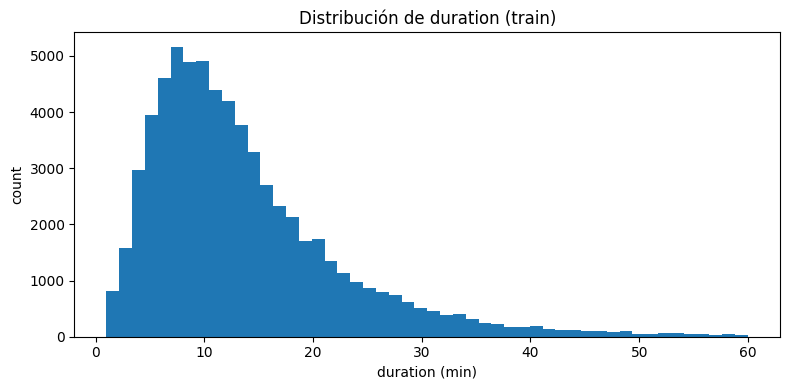

ehail_fee                1.000000
trip_type                0.065129
store_and_fwd_flag       0.065053
congestion_surcharge     0.065053
passenger_count          0.065053
payment_type             0.065053
RatecodeID               0.065053
tolls_amount             0.000000
total_amount             0.000000
improvement_surcharge    0.000000
dtype: float64

In [21]:
import matplotlib.pyplot as plt

# Distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_jan["duration"], bins=50)
ax.set_title("Distribución de duration (train)")
ax.set_xlabel("duration (min)")
ax.set_ylabel("count")
fig.tight_layout()
plt.show()

# Missingness simple
missing = df_jan.isna().mean().sort_values(ascending=False).head(10)
missing

## **Definir columnas a modelar**

In [22]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ["trip_distance"]

## Definir set de train y test

In [23]:
df_train = df_jan
df_val = df_feb

## **Preprocesar**

### ¿Por qué convertir las columnas categóricas a un diccionario?

Un modelo como `RandomForestRegressor` solo entiende números — no sabe qué hacer con una columna como `PULocationID` si queremos tratarla como una etiqueta en vez de como una cantidad. Para eso existe `DictVectorizer` de scikit-learn: convierte un diccionario de atributos (`{nombre_del_atributo: valor}`) en un vector numérico, y lo hace de forma distinta según si el valor es un número o un texto (lo vemos en detalle más abajo).

Por eso, antes de usarlo, la celda de abajo arma un diccionario por cada fila con `to_dict(orient="records")`. Por ejemplo, para un viaje cualquiera del dataset, una fila de `categorical` como esta:

| PULocationID | DOLocationID |
|---|---|
| 43 | 238 |

se convierte en el diccionario:

```python
{"PULocationID": 43, "DOLocationID": 238}
```

Y `df_train["categorical_dict"]` termina siendo una columna donde cada celda es uno de estos diccionarios, uno por viaje. Eso es justo lo que espera `DictVectorizer`: una lista de diccionarios, uno por muestra.

### ¿Qué hace `DictVectorizer` con esos diccionarios?

La regla de `DictVectorizer` depende del tipo de dato de cada valor:

| Tipo de valor | ¿Cómo lo trata? | Resultado |
|---|---|---|
| Texto (`str`) | Como una **categoría** | Una columna binaria (0/1) por cada `llave=valor` distinto visto en los datos — *one-hot encoding* |
| Número (`int` / `float`) | Lo deja igual | Una sola columna numérica, sin cambios |

Esto importa mucho acá: en el archivo `jan.parquet`, `PULocationID` y `DOLocationID` están guardadas como enteros (`int64`), no como texto. Según la tabla de arriba, eso cae en la segunda fila — no en la primera. Vale la pena verlo con un ejemplo chiquito antes de seguir.

In [24]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

df_train = df_train.copy()
df_val   = df_val.copy()
df_train["categorical_dict"] = df_train[categorical].to_dict(orient="records")
df_val["categorical_dict"]   = df_val[categorical].to_dict(orient="records")

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", DictVectorizer(), "categorical_dict"),
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), numerical),
    ]
)

X_train = preprocessor.fit_transform(df_train)
y_train = df_train["duration"].values
X_val   = preprocessor.transform(df_val)
y_val   = df_val["duration"].values









#### Ejemplo 1: valores numéricos (lo que pasa hoy en esta celda)

In [25]:
from sklearn.feature_extraction import DictVectorizer

# Ejemplo mínimo, con solo 3 "viajes" de juguete, para ver exactamente
# qué hace DictVectorizer cuando los valores del diccionario son números
# (como PULocationID/DOLocationID en jan.parquet, que son int64).
ejemplo_numerico = [
    {"PULocationID": 43, "DOLocationID": 238},
    {"PULocationID": 100, "DOLocationID": 43},
    {"PULocationID": 238, "DOLocationID": 100},
]

dv_numerico = DictVectorizer(sparse=True)
X_numerico = dv_numerico.fit_transform(ejemplo_numerico)

print("Columnas generadas:", list(dv_numerico.get_feature_names_out()))
print("Matriz (convertida a densa solo para poder imprimirla):")
print(X_numerico.toarray())

Columnas generadas: ['DOLocationID', 'PULocationID']
Matriz (convertida a densa solo para poder imprimirla):
[[238.  43.]
 [ 43. 100.]
 [100. 238.]]


Esto fue exactamente lo que devolvió `DictVectorizer` para los 3 viajes de juguete (mismo orden que `dv_numerico.get_feature_names_out()`):

| Viaje | dict de entrada | DOLocationID | PULocationID |
|---|---|---|---|
| 1 | `{"PULocationID": 43, "DOLocationID": 238}` | 238.0 | 43.0 |
| 2 | `{"PULocationID": 100, "DOLocationID": 43}` | 43.0 | 100.0 |
| 3 | `{"PULocationID": 238, "DOLocationID": 100}` | 100.0 | 238.0 |

No se creó ninguna columna nueva por zona — son las mismas 2 columnas de siempre, con los valores originales intactos. **0% de ceros**: técnicamente sigue siendo un objeto `sparse` (porque pedimos `sparse=True`), pero no tiene nada de disperso *en la práctica*. El `RandomForestRegressor` termina recibiendo estos IDs de zona como si fueran cantidades continuas — como si la zona 238 fuera "más" que la zona 43 en algún sentido numérico, algo que no tiene significado real para un identificador.

#### Ejemplo 2: los mismos datos, pero como texto (lo que sí produce un vector disperso)

In [26]:
# Los mismos tres viajes, pero convirtiendo las zonas a texto antes de
# armar el diccionario -así es como DictVectorizer sí las trata como
# categorías.
ejemplo_categorico = [
    {"PULocationID": "43", "DOLocationID": "238"},
    {"PULocationID": "100", "DOLocationID": "43"},
    {"PULocationID": "238", "DOLocationID": "100"},
]

dv_categorico = DictVectorizer(sparse=True)
X_categorico = dv_categorico.fit_transform(ejemplo_categorico)

print("Columnas generadas:", list(dv_categorico.get_feature_names_out()))
print("Matriz (convertida a densa solo para poder imprimirla):")
print(X_categorico.toarray())

total_entradas = X_categorico.shape[0] * X_categorico.shape[1]
print(f"\nCeros: {(1 - X_categorico.nnz / total_entradas) * 100:.1f}% de la matriz")

Columnas generadas: ['DOLocationID=100', 'DOLocationID=238', 'DOLocationID=43', 'PULocationID=100', 'PULocationID=238', 'PULocationID=43']
Matriz (convertida a densa solo para poder imprimirla):
[[0. 1. 0. 0. 0. 1.]
 [0. 0. 1. 1. 0. 0.]
 [1. 0. 0. 0. 1. 0.]]

Ceros: 66.7% de la matriz


Ahora sí aparecieron columnas nuevas — una por cada combinación distinta de `llave=valor`. Esta es la misma matriz que `dv_categorico.get_feature_names_out()` y `X_categorico.toarray()` acaban de imprimir, pero en tabla (en **negrita** los únicos valores que sí son 1):

| Viaje | dict de entrada | DO=100 | DO=238 | DO=43 | PU=100 | PU=238 | PU=43 |
|---|---|---|---|---|---|---|---|
| 1 | `{"PULocationID": "43", "DOLocationID": "238"}` | 0 | **1** | 0 | 0 | 0 | **1** |
| 2 | `{"PULocationID": "100", "DOLocationID": "43"}` | 0 | 0 | **1** | **1** | 0 | 0 |
| 3 | `{"PULocationID": "238", "DOLocationID": "100"}` | **1** | 0 | 0 | 0 | **1** | 0 |

Cada fila tiene exactamente dos `1` (su zona de recogida y su zona de destino) y el resto en `0`. Con solo 3 ejemplos de juguete ya quedó con un 66.7% de ceros.

Esto es justamente lo que se conoce como **vector disperso (sparse vector)**: un vector, o matriz, donde la gran mayoría de las entradas son cero y solo un puñado son distintas de cero. En Nueva York hay unas 265 zonas de taxi registradas por la TLC — si hiciéramos esto con `PULocationID` y `DOLocationID` reales, tendríamos hasta unas 530 columnas (265 + 265), y cada viaje seguiría "encendiendo" solamente 2 de esas ~530 columnas: **más del 99.6% de ceros por fila**.

| | Array denso (`numpy.ndarray`) | Matriz dispersa (`scipy.sparse.csr_matrix`) |
|---|---|---|
| ¿Qué guarda? | Cada una de las celdas, ceros incluidos | Solo las coordenadas (fila, columna) y el valor de las celdas que **no** son cero |
| Con 530 columnas y 99.6% de ceros | Reserva memoria para las 530 celdas de cada fila | Reserva memoria solo para las 2 celdas "encendidas" de cada fila |

Por eso scikit-learn devuelve un `csr_matrix` (Compressed Sparse Row) en vez de un array denso — es exactamente lo que ves en su `repr` (`"with N stored elements"`): solo cuenta y guarda los valores reales, no los ceros.

### Nota sobre este notebook en particular

Vale la pena que lo tengan claro en clase: en la celda de "Preprocesar" de arriba, como `PULocationID`/`DOLocationID` llegan como `int64` desde `jan.parquet`/`feb.parquet`, el `DictVectorizer` de ese pipeline se está comportando como el **Ejemplo 1** (numérico, sin one-hot) y no como el **Ejemplo 2** (categórico, disperso de verdad). Si la intención del ejercicio es que el modelo trate las zonas como categorías -que es lo más razonable para un identificador de zona-, haría falta convertir esas columnas a texto antes de construir el diccionario, por ejemplo:

```python
df_train[categorical] = df_train[categorical].astype(str)
df_val[categorical] = df_val[categorical].astype(str)
```

justo antes de la línea `df_train["categorical_dict"] = ...`. Esto no se modificó en la celda de código -se deja señalado aquí como parte de la explicación- para que se decida si se ajusta ahí o si se deja así a propósito, como contraste pedagógico entre los dos ejemplos de arriba.

## **Entrenar**

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=0, max_depth=10)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)


## **Metricas de modelado**

In [28]:
from sklearn.metrics import root_mean_squared_error


rmse = root_mean_squared_error(y_val, y_pred)

In [29]:
rmse

5.137713717868471

## Análisis: 

1. Si el resultado de `rmse` de esta celda fuera el mejor que han obtenido hasta ahora,
   ?como se lo demostrarian a alguien mas manana, si ya cerraron esta notebook?
2. Si quisieran comparar este RandomForest contra un XGBoost y contra 5 combinaciones
   distintas de hiperparametros, ?que tendrian que hacer manualmente hoy para no perder
   el rastro de cada intento?
3. Nombren al menos 3 piezas de informacion que NO quedaron guardadas en ningun lado
   (pista: parametros, version de datos, artefactos, codigo exacto).

